<a href="https://colab.research.google.com/github/JainamSavla/QuantHackathon_IITMandi/blob/main/quant_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QuantQuest: ML-Based Momentum Trading Strategy
**E-Summit '26 (Xpecto), IIT Mandi**

---

## Overview
- **Objective:** Predict whether each of 10 stocks will generate a positive return over the next week using ML classification.
- **Universe:** AAPL, MSFT, GOOGL, AMZN, META, TSLA, JPM, V, JNJ, BRK-B
- **Strategy:** Each week, rank stocks by predicted probability, pick the top 2, equal-weight long-only portfolio, hold 1 week, rebalance.
- **Transaction Costs:** 0.1% at entry + 0.1% at exit (0.2% round-trip per stock change).
- **Train:** 2017–2022 | **Test:** 2023–2025

## 1. Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
    print('LightGBM available ✓')
except ImportError:
    HAS_LGBM = False
    print('LightGBM not installed — run: pip install lightgbm')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'V', 'JNJ', 'BRK-B']
TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'
TC = 0.001  # 0.1% transaction cost per leg
TOP_K = 3   # increased from 2→3 for better diversification and lower volatility

print('Setup complete.')

LightGBM available ✓
Setup complete.


## 2. Data Download

In [ ]:
raw = yf.download(TICKERS, start='2017-01-01', end='2025-12-31', auto_adjust=True)
print(f'Downloaded data shape: {raw.shape}')
print(f'Date range: {raw.index.min().date()} to {raw.index.max().date()}')
raw.head()

[*********************100%***********************]  10 of 10 completed

Downloaded data shape: (2261, 50)
Date range: 2017-01-03 to 2025-12-30


Price        Close                                                            \
Ticker        AAPL    AMZN    BRK-B   GOOGL     JNJ     JPM     META    MSFT   
Date                                                                           
2017-01-03 26.7459 37.6835 163.8300 40.0693 89.8225 68.2121 116.0494 56.1711   
2017-01-04 26.7159 37.8590 164.0800 40.0574 89.6751 68.3379 117.8667 55.9198   
2017-01-05 26.8518 39.0225 163.3000 40.3178 90.6134 67.7089 119.8329 55.9198   
2017-01-06 27.1511 39.7995 163.4100 40.9223 90.1792 67.7168 122.5539 56.4045   
2017-01-09 27.3998 39.8460 162.0200 41.0200 90.1636 67.7639 124.0336 56.2250   

Price                         High                                           \
Ticker        TSLA       V    AAPL    AMZN    BRK-B   GOOGL     JNJ     JPM   
Date                                                                          
2017-01-03 14.4660 74.5305 26.7873 37.9380 164.7100 40.2394 89.9465 68.6266   
2017-01-04 15.1327 75.1398 26.8288 37.9840 164.5700 40.3381 90.1249 68.5502   
2017-01-05 15.1167 76.0211 26.9094 39.1200 164.1400 40.3535 90.6987 68.4952   
2017-01-06 15.2673 77.0711 27.2087 39.9720 163.8000 41.1082 90.7219 68.1099   
2017-01-09 15.4187 76.6398 27.5011 40.0885 163.2500 41.1811 90.4195 68.2279   

Price                                           Low                           \
Ticker         META    MSFT    TSLA       V    AAPL    AMZN    BRK-B   GOOGL   
Date                                                                           
2017-01-03 117.0226 56.4045 14.6887 74.9148 26.4258 37.3850 162.4400 39.5179   
2017-01-04 118.8299 56.3237 15.2000 75.2430 26.6537 37.7100 163.0000 39.8759   
2017-01-05 120.1110 56.2429 15.1653 76.4336 26.6676 38.0130 162.1800 39.9657   
2017-01-06 123.0207 56.6827 15.3540 77.3335 26.8195 38.9240 162.6400 40.2424   
2017-01-09 124.5599 56.6199 15.4613 77.2961 27.1580 39.5885 162.0200 40.7443   

Price                                                          Open          \
Ticker         JNJ     JPM     META    MSFT    TSLA       V    AAPL    AMZN   
Date                                                                          
2017-01-03 89.3495 67.2347 114.7087 55.7672 14.0640 73.5836 26.6653 37.8960   
2017-01-04 89.4115 67.9369 116.4764 55.7582 14.2873 74.3992 26.6768 37.9195   
2017-01-05 89.5123 67.0405 117.4992 55.6774 14.7967 75.2055 26.6929 38.0775   
2017-01-06 89.7604 67.5752 119.1974 55.6864 15.0300 75.8804 26.8909 39.1180   
2017-01-09 89.8612 67.2450 122.1865 56.1352 15.2000 76.5461 27.1603 39.9000   

Price                                                                         \
Ticker        BRK-B   GOOGL     JNJ     JPM     META    MSFT    TSLA       V   
Date                                                                           
2017-01-03 164.3400 39.7029 89.7759 68.2981 115.2251 56.3596 14.3240 73.8367   
2017-01-04 164.4500 40.1626 89.5588 68.3773 116.7346 56.0814 14.3167 74.4742   
2017-01-05 164.0600 40.0440 89.9465 68.2593 118.0355 55.8210 15.0947 75.3180   
2017-01-06 163.4400 40.4155 90.4660 67.9291 120.1408 55.9198 15.1287 76.2179   
2017-01-09 163.0400 40.9798 90.2179 67.4101 122.6929 56.3327 15.2647 77.1367   

Price          Volume                                                   \
Ticker           AAPL       AMZN    BRK-B     GOOGL      JNJ       JPM   
Date                                                                     
2017-01-03  115127600   70422000  4091000  39180000  5953000  20550700   
2017-01-04   84472400   50210000  3568900  30306000  5828900  15266600   
2017-01-05   88774400  116602000  2982500  26810000  6217200  14300800   
2017-01-06  127007600  119724000  2697000  40342000  5221400  12893300   
2017-01-09  134247600   68922000  3564700  28178000  5457500  12806600   

Price                                                
Ticker          META      MSFT       TSLA         V  
Date                                                 
2017-01-03  20663900  20694100   88849500  13785200  
20

In [ ]:
# Build per-ticker DataFrames
close = raw['Close'][TICKERS].copy()
high = raw['High'][TICKERS].copy()
low = raw['Low'][TICKERS].copy()
volume = raw['Volume'][TICKERS].copy()
opn = raw['Open'][TICKERS].copy()

# Forward-fill then drop any remaining NaNs at the start
close = close.ffill().dropna()
high = high.reindex(close.index).ffill().dropna()
low = low.reindex(close.index).ffill().dropna()
volume = volume.reindex(close.index).ffill().dropna()
opn = opn.reindex(close.index).ffill().dropna()

print(f'Clean close data: {close.shape}')
close.tail()

Clean close data: (2261, 10)


Ticker,AAPL,MSFT,GOOGL,AMZN,META,TSLA,JPM,V,JNJ,BRK-B
Date,,,,,,,,,,
2025-12-23,272.1054,485.7413,314.1289,232.1400,664.9400,485.5600,324.4664,352.6528,204.6918,500.5100
2025-12-24,273.5540,486.9086,313.8690,232.3800,667.5500,485.4000,327.6919,354.4092,206.6813,501.3400
2025-12-26,273.1444,486.5994,313.2895,232.5200,663.2900,475.1900,326.4375,354.2695,206.5321,498.3000
2025-12-29,273.5041,485.9908,313.3394,232.0700,658.6900,459.6400,322.2962,353.8802,206.4624,501.0500
2025-12-30,272.8247,486.3699,313.6292,232.5300,665.9500,454.4300,321.9677,352.8923,205.8159,503.7100


## 3. Feature Engineering

For each stock, we compute technical/momentum features on a **daily** basis, then resample to **weekly** for model training.

### Features:
| Feature | Description |
|---|---|
| `ret_1w` to `ret_12w` | Past 1/2/4/8/12 week returns |
| `vol_4w` | 4-week realized volatility |
| `rsi_14` | 14-day RSI |
| `macd_signal` | MACD minus signal line |
| `bb_pct` | Bollinger Band %B |
| `avg_volume_ratio` | Current vs 20-day avg volume |
| `atr_pct` | ATR as % of close |
| `ret_52w_high_dist` | Distance from 52-week high |
| `skew_4w` | 4-week return skewness |

In [ ]:
daily_ret = close.pct_change()

def compute_features(ticker):
    """Compute feature set for a single ticker. Returns a DataFrame indexed by date."""
    c = close[ticker]
    h = high[ticker]
    l = low[ticker]
    v = volume[ticker]
    r = daily_ret[ticker]

    feat = pd.DataFrame(index=c.index)

    # Momentum returns (lookback in trading days: 1w~5d, 2w~10d, etc.)
    for weeks, days in [(1, 5), (2, 10), (4, 20), (8, 40), (12, 60)]:
        feat[f'ret_{weeks}w'] = c.pct_change(days)

    # Realized volatility (4 weeks)
    feat['vol_4w'] = r.rolling(20).std() * np.sqrt(252)

    # RSI 14-day
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    feat['rsi_14'] = 100 - 100 / (1 + rs)

    # MACD
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    feat['macd_signal'] = (macd_line - signal_line) / c  # normalized

    # Bollinger Band %B
    sma20 = c.rolling(20).mean()
    std20 = c.rolling(20).std()
    feat['bb_pct'] = (c - (sma20 - 2 * std20)) / (4 * std20)

    # Volume ratio
    feat['avg_volume_ratio'] = v / v.rolling(20).mean()

    # ATR %
    tr = pd.concat([
        h - l,
        (h - c.shift(1)).abs(),
        (l - c.shift(1)).abs()
    ], axis=1).max(axis=1)
    feat['atr_pct'] = tr.rolling(14).mean() / c

    # Distance from 52-week high
    feat['ret_52w_high_dist'] = c / c.rolling(252).max() - 1

    # Skewness of daily returns over 4 weeks
    feat['skew_4w'] = r.rolling(20).skew()

    return feat

# Compute features for all tickers
all_features = {}
for t in TICKERS:
    all_features[t] = compute_features(t)

print(f'Features computed. Columns: {list(all_features["AAPL"].columns)}')

Features computed. Columns: ['ret_1w', 'ret_2w', 'ret_4w', 'ret_8w', 'ret_12w', 'vol_4w', 'rsi_14', 'macd_signal', 'bb_pct', 'avg_volume_ratio', 'atr_pct', 'ret_52w_high_dist', 'skew_4w']


## 4. Weekly Resampling & Target Construction

In [ ]:
# Resample close to weekly (Friday close)
weekly_close = close.resample('W-FRI').last()
weekly_ret = weekly_close.pct_change()  # actual weekly return

# Target: will next week's return be positive?
target = (weekly_ret.shift(-1) > 0).astype(int)  # shifted so target[t] = sign of return from t to t+1

# Resample features to weekly (take Friday's value, i.e., last of the week)
weekly_features = {}
for t in TICKERS:
    weekly_features[t] = all_features[t].resample('W-FRI').last()

print(f'Weekly periods: {weekly_close.shape[0]}')
print(f'Target positive rate (AAPL): {target["AAPL"].mean():.2%}')

Weekly periods: 470
Target positive rate (AAPL): 58.94%


In [ ]:
# Precompute weekly realised volatility per stock (used for position sizing)
# We use 4-week (20-day) rolling daily vol, resampled to Friday close
daily_ret_all = close.pct_change()
weekly_vol = daily_ret_all.rolling(20).std().resample('W-FRI').last() * np.sqrt(52)
print(f'Weekly vol matrix shape: {weekly_vol.shape}')
weekly_vol.tail(3)

Weekly vol matrix shape: (470, 10)


Ticker,AAPL,MSFT,GOOGL,AMZN,META,TSLA,JPM,V,JNJ,BRK-B
Date,,,,,,,,,,
2025-12-19,0.0676,0.0929,0.1577,0.0956,0.1261,0.1881,0.1213,0.1124,0.0881,0.0653
2025-12-26,0.0569,0.0851,0.1045,0.0842,0.1039,0.1656,0.1213,0.1095,0.0875,0.0657
2026-01-02,0.0491,0.0802,0.1011,0.0792,0.0981,0.1782,0.1188,0.1071,0.0866,0.0648


In [ ]:
# Precompute SPY 20-week moving average for market regime filter
# When SPY is below its 20-week MA → bear/risk-off regime → hold cash
spy_full = yf.download('SPY', start='2017-01-01', end='2025-12-31', auto_adjust=True)
spy_full_close = spy_full['Close']
if isinstance(spy_full_close, pd.DataFrame):
    spy_full_close = spy_full_close.squeeze()
spy_weekly_full = spy_full_close.resample('W-FRI').last()
spy_ma20 = spy_weekly_full.rolling(20).mean()
# Regime: 1 = SPY above MA (invest), 0 = SPY below MA (hold cash)
spy_regime = (spy_weekly_full > spy_ma20).astype(int)
print(f'SPY regime computed. Risk-ON weeks: {spy_regime.sum()} / {len(spy_regime)} total')
print(f'Pct weeks in risk-ON regime: {spy_regime.mean():.1%}')

[*********************100%***********************]  1 of 1 completed

SPY regime computed. Risk-ON weeks: 356 / 470 total
Pct weeks in risk-ON regime: 75.7%


## 5. Build Training & Test Datasets

In [ ]:
feature_cols = list(all_features['AAPL'].columns)

rows = []
for t in TICKERS:
    df = weekly_features[t][feature_cols].copy()
    df['target'] = target[t]
    df['ticker'] = t
    df['week'] = df.index
    rows.append(df)

master = pd.concat(rows).dropna().reset_index(drop=True)
print(f'Master dataset: {master.shape}')

train = master[master['week'] <= TRAIN_END].copy()
test = master[master['week'] >= TEST_START].copy()

print(f'Train: {train.shape}  ({train["week"].min().date()} to {train["week"].max().date()})')
print(f'Test:  {test.shape}  ({test["week"].min().date()} to {test["week"].max().date()})')
print(f'\nTarget distribution (train):\n{train["target"].value_counts(normalize=True)}')

Master dataset: (4179, 16)
Train: (2610, 16)  (2018-01-05 to 2022-12-30)
Test:  (1569, 16)  (2023-01-06 to 2026-01-02)

Target distribution (train):
target
1   0.5464
0   0.4536
Name: proportion, dtype: float64


## 6. Model Training

We use a **soft-voting ensemble** of 4 classifiers:
1. **Logistic Regression** — linear baseline, acts as regularising anchor
2. **Random Forest** — non-linear, handles feature interactions
3. **XGBoost** — gradient boosted trees, strongest individual performer
4. **LightGBM** — modern boosting variant, often superior on small tabular datasets

Soft voting averages predicted probabilities, giving us a continuous ranking score to select the top 2 stocks each week.

In [ ]:
# TimeSeriesSplit cross-validation on training data
X_train_raw = train[feature_cols].values
y_train_raw = train['target'].values

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {'accuracy': [], 'roc_auc': []}

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_raw), 1):
    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_train_raw[tr_idx])
    X_val = sc.transform(X_train_raw[val_idx])
    y_tr, y_val = y_train_raw[tr_idx], y_train_raw[val_idx]

    estimators_cv = [
        ('lr',  LogisticRegression(C=0.1, max_iter=1000, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=6,
                                       min_samples_leaf=20, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=42, verbosity=0)),  # use_label_encoder removed in XGBoost 2.0
    ]
    weights_cv = [1, 2, 2]

    if HAS_LGBM:
        estimators_cv.append(
            ('lgbm', LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbose=-1))
        )
        weights_cv.append(2)

    cv_model = VotingClassifier(estimators=estimators_cv, voting='soft', weights=weights_cv)
    cv_model.fit(X_tr, y_tr)
    y_val_pred = cv_model.predict(X_val)
    y_val_prob = cv_model.predict_proba(X_val)[:, 1]

    cv_scores['accuracy'].append(accuracy_score(y_val, y_val_pred))
    cv_scores['roc_auc'].append(roc_auc_score(y_val, y_val_prob))
    print(f'  Fold {fold}: Accuracy={cv_scores["accuracy"][-1]:.4f}  ROC-AUC={cv_scores["roc_auc"][-1]:.4f}')

print(f'\nTimeSeriesSplit CV (5-fold) on training data:')
print(f'  Mean Accuracy : {np.mean(cv_scores["accuracy"]):.4f} +/- {np.std(cv_scores["accuracy"]):.4f}')
print(f'  Mean ROC-AUC  : {np.mean(cv_scores["roc_auc"]):.4f} +/- {np.std(cv_scores["roc_auc"]):.4f}')

  Fold 1: Accuracy=0.5333  ROC-AUC=0.5405
  Fold 2: Accuracy=0.5448  ROC-AUC=0.5759
  Fold 3: Accuracy=0.4897  ROC-AUC=0.4758
  Fold 4: Accuracy=0.5057  ROC-AUC=0.5147
  Fold 5: Accuracy=0.5770  ROC-AUC=0.5710

TimeSeriesSplit CV (5-fold) on training data:
  Mean Accuracy : 0.5301 +/- 0.0305
  Mean ROC-AUC  : 0.5356 +/- 0.0372


In [ ]:
X_train = train[feature_cols].values
y_train = train['target'].values
X_test  = test[feature_cols].values
y_test  = test['target'].values

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Individual models
lr  = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=300, max_depth=6,
                              min_samples_leaf=20, random_state=42, n_jobs=-1)
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0)  # use_label_encoder removed in XGBoost 2.0

estimators = [('lr', lr), ('rf', rf), ('xgb', xgb)]
weights     = [1, 2, 2]

if HAS_LGBM:
    lgbm = LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           random_state=42, verbose=-1)
    estimators.append(('lgbm', lgbm))
    weights.append(2)
    print('Ensemble: LR + RF + XGBoost + LightGBM  (weights: 1-2-2-2)')
else:
    print('Ensemble: LR + RF + XGBoost  (weights: 1-2-2)  [install lightgbm to add 4th model]')

ensemble = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
ensemble.fit(X_train_s, y_train)
print('Ensemble trained successfully.')

Ensemble: LR + RF + XGBoost + LightGBM  (weights: 1-2-2-2)
Ensemble trained successfully.


In [ ]:
# Predictions on test set
y_pred = ensemble.predict(X_test_s)
y_prob = ensemble.predict_proba(X_test_s)[:, 1]  # P(positive return)

print('=== Classification Report (Test Set) ===')
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

        Down       0.42      0.26      0.32       674
          Up       0.57      0.72      0.63       895

    accuracy                           0.53      1569
   macro avg       0.49      0.49      0.48      1569
weighted avg       0.50      0.53      0.50      1569

Accuracy : 0.5252
ROC-AUC  : 0.5018


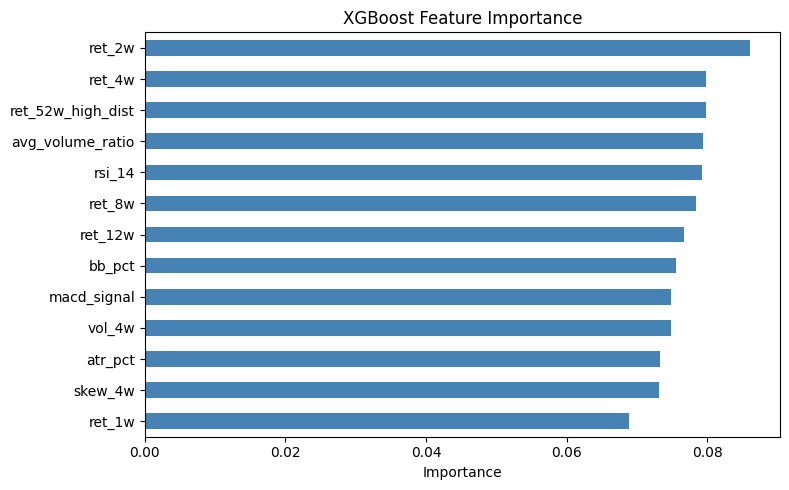

In [ ]:
# Feature importance from the XGBoost component
xgb_model = ensemble.named_estimators_['xgb']
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Portfolio Construction & Backtest

**Logic:**
1. Each Friday, predict P(positive next-week return) for all 10 stocks.
2. Rank by probability, select top 2.
3. Equal-weight (50/50) long-only portfolio.
4. Hold for 1 week, rebalance next Friday.
5. Apply 0.1% transaction cost at entry and 0.1% at exit for changed positions.

In [ ]:
# Add predictions back to test dataframe
test = test.copy()
test['pred_prob'] = y_prob
test['pred'] = y_pred

# Get unique test weeks
test_weeks = sorted(test['week'].unique())
print(f'Test weeks: {len(test_weeks)} (from {test_weeks[0].date()} to {test_weeks[-1].date()})')

Test weeks: 157 (from 2023-01-06 to 2026-01-02)


In [ ]:
# Weekly stock selection and portfolio returns
# Improvements:
#   1. Market regime filter — hold cash when SPY < 20-week MA
#   2. Volatility-scaled position sizing — lower weight to more volatile stocks
portfolio_records = []
prev_holdings = set()

for i, week in enumerate(test_weeks[:-1]):  # skip last week (no future return)
    week_data = test[test['week'] == week].copy()

    # ── Regime filter: skip this week if market is in downtrend ──────
    regime = spy_regime.get(week, 1)  # default to 1 (invest) if date not found
    if regime == 0:
        # Hold cash — record a 0% return week with no TC
        portfolio_records.append({
            'week': week,
            'next_week': test_weeks[i + 1],
            'stock_1': 'CASH',
            'stock_2': 'CASH',
            'stock_3': 'CASH' if TOP_K >= 3 else None,
            'weight_1': 0.0,
            'weight_2': 0.0,
            'weight_3': 0.0,
            'return_gross': 0.0,
            'turnover_cost': 0.0,
            'return_net': 0.0,
            'n_changes': len(prev_holdings),  # cost of liquidating
            'regime': 0,
        })
        prev_holdings = set()
        continue

    # Rank by predicted probability
    week_data = week_data.sort_values('pred_prob', ascending=False)

    # Select top K stocks
    top_stocks = week_data.head(TOP_K)['ticker'].tolist()
    current_holdings = set(top_stocks)

    # Compute actual next-week returns for selected stocks
    next_week = test_weeks[i + 1]

    stock_returns = []
    for t in top_stocks:
        if next_week in weekly_ret.index:
            ret = weekly_ret.loc[next_week, t]
            stock_returns.append(ret)

    if len(stock_returns) == 0:
        continue

    # ── Volatility-scaled weights ─────────────────────────────────────
    # Weight each stock inversely proportional to its recent volatility
    # Lower vol stock → higher weight. Normalised so weights sum to 1.
    vols = []
    for t in top_stocks:
        v = weekly_vol.loc[week, t] if week in weekly_vol.index else 0.20
        vols.append(max(v, 0.05))  # floor at 5% to avoid division by zero

    inv_vols = [1.0 / v for v in vols]
    total_inv = sum(inv_vols)
    weights = [iv / total_inv for iv in inv_vols]

    # Portfolio return = weighted sum of stock returns
    port_ret_gross = sum(w * r for w, r in zip(weights, stock_returns))

    # Transaction costs
    n_buy  = len(current_holdings - prev_holdings)
    n_sell = len(prev_holdings - current_holdings)
    # Use average weight for TC (vol-scaled weights vary so use mean)
    avg_weight = 1.0 / TOP_K
    turnover_cost = (n_buy + n_sell) * avg_weight * TC
    port_ret_net = port_ret_gross - turnover_cost

    record = {
        'week': week,
        'next_week': next_week,
        'stock_1': top_stocks[0],
        'stock_2': top_stocks[1] if len(top_stocks) > 1 else None,
        'weight_1': round(weights[0], 4),
        'weight_2': round(weights[1], 4) if len(weights) > 1 else 0,
        'return_gross': port_ret_gross,
        'turnover_cost': turnover_cost,
        'return_net': port_ret_net,
        'n_changes': n_buy + n_sell,
        'regime': 1,
    }
    if TOP_K >= 3:
        record['stock_3'] = top_stocks[2] if len(top_stocks) > 2 else None
        record['weight_3'] = round(weights[2], 4) if len(weights) > 2 else 0

    portfolio_records.append(record)
    prev_holdings = current_holdings

portfolio_df = pd.DataFrame(portfolio_records)
portfolio_df = portfolio_df.set_index('week')

invested_weeks = (portfolio_df['regime'] == 1).sum()
cash_weeks     = (portfolio_df['regime'] == 0).sum()
print(f'Backtest periods: {len(portfolio_df)}')
print(f'  Invested weeks : {invested_weeks}  ({invested_weeks/len(portfolio_df):.1%})')
print(f'  Cash weeks     : {cash_weeks}  ({cash_weeks/len(portfolio_df):.1%})')
portfolio_df[['stock_1', 'stock_2', 'weight_1', 'weight_2', 'return_gross', 'return_net', 'regime']].head(10)

Backtest periods: 156
  Invested weeks : 137  (87.8%)
  Cash weeks     : 19  (12.2%)


,stock_1,stock_2,weight_1,weight_2,return_gross,return_net,regime
week,,,,,,,
2023-01-06,JPM,TSLA,0.4984,0.0909,0.0245,0.0235,1
2023-01-13,BRK-B,AMZN,0.4841,0.2194,-0.0126,-0.0139,1
2023-01-20,BRK-B,JPM,0.3809,0.3800,0.0172,0.0158,1
2023-01-27,JPM,V,0.3158,0.3168,-0.0008,-0.0015,1
2023-02-03,JNJ,BRK-B,0.3903,0.4393,-0.0205,-0.0218,1
2023-02-10,META,BRK-B,0.0885,0.5247,-0.0001,-0.0015,1
2023-02-17,BRK-B,JNJ,0.5499,0.3736,-0.0189,-0.0196,1
2023-02-24,JNJ,META,0.6314,0.1332,0.0157,0.0150,1
2023-03-03,BRK-B,AAPL,0.4135,0.2340,-0.0402,-0.0422,1


## 8. Benchmark: Equal-Weight Buy & Hold

In [ ]:
# Equal-weight benchmark of all 10 stocks
# Use .reindex() instead of .loc[] — safer if any dates don't align perfectly
benchmark_ret = weekly_ret.reindex(portfolio_df['next_week']).mean(axis=1)
benchmark_ret.index = portfolio_df.index

# SPY benchmark — handle both old yfinance (Series) and new yfinance (DataFrame) output
spy = yf.download('SPY', start='2017-01-01', end='2025-12-31', auto_adjust=True)
spy_close = spy['Close']
if isinstance(spy_close, pd.DataFrame):
    spy_close = spy_close.squeeze()  # DataFrame with 1 col → Series
spy_weekly = spy_close.resample('W-FRI').last().pct_change()
spy_aligned = spy_weekly.reindex(portfolio_df['next_week'])
spy_aligned.index = portfolio_df.index

print('Benchmarks computed.')

[*********************100%***********************]  1 of 1 completed

Benchmarks computed.


## 9. Performance Metrics

In [ ]:
def compute_metrics(returns_series, name='Strategy'):
    """Compute key performance metrics from a weekly return series."""
    r = returns_series.dropna()
    cumulative = (1 + r).cumprod()
    total_ret = cumulative.iloc[-1] - 1
    n_weeks = len(r)
    n_years = n_weeks / 52

    ann_ret = (1 + total_ret) ** (1 / n_years) - 1
    ann_vol = r.std() * np.sqrt(52)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    # Max drawdown
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    # Calmar Ratio = Annualized Return / |Max Drawdown|
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    # Hit rate
    hit_rate = (r > 0).mean()
    avg_weekly = r.mean()

    return {
        'Name': name,
        'Cumulative Return': f'{total_ret:.2%}',
        'Annualized Return': f'{ann_ret:.2%}',
        'Annualized Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio': f'{sharpe:.3f}',
        'Calmar Ratio': f'{calmar:.3f}',
        'Max Drawdown': f'{max_dd:.2%}',
        'Hit Rate': f'{hit_rate:.2%}',
        'Avg Weekly Return': f'{avg_weekly:.4%}',
        'Total Weeks': n_weeks
    }

metrics_gross = compute_metrics(portfolio_df['return_gross'], 'Strategy (Before TC)')
metrics_net   = compute_metrics(portfolio_df['return_net'],   'Strategy (After TC)')
metrics_bench = compute_metrics(benchmark_ret,                'Equal-Weight 10 Stocks')
metrics_spy   = compute_metrics(spy_aligned.squeeze(),        'SPY')

metrics_table = pd.DataFrame([metrics_gross, metrics_net, metrics_bench, metrics_spy]).set_index('Name')
metrics_table

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Calmar Ratio,Max Drawdown,Hit Rate,Avg Weekly Return,Total Weeks
Name,,,,,,,,,
Strategy (Before TC),130.15%,32.03%,12.63%,2.536,4.345,-7.37%,56.41%,0.5510%,156
Strategy (After TC),95.88%,25.12%,12.62%,1.991,3.082,-8.15%,54.49%,0.4471%,156
Equal-Weight 10 Stocks,168.18%,38.93%,17.01%,2.289,2.094,-18.59%,63.46%,0.6619%,156
SPY,84.16%,22.57%,14.40%,1.567,1.338,-16.88%,59.62%,0.4121%,156


## 9b. Correlation Analysis & Stock Pick Frequency

In [ ]:
# Strategy vs SPY correlation
corr_spy = portfolio_df['return_net'].corr(spy_aligned.squeeze())
print(f'Correlation of strategy (net) with SPY: {corr_spy:.3f}')
print('(Lower correlation = more independent alpha)')

# Stock selection frequency
print()
print('Stock selection frequency (test period):')
all_picks = portfolio_df['stock_1'].tolist() + portfolio_df['stock_2'].tolist()
pick_freq = pd.Series(all_picks).value_counts().rename('times_selected')
pick_pct  = (pick_freq / len(portfolio_df) * 100).round(1).rename('% of weeks')
print(pd.concat([pick_freq, pick_pct], axis=1).to_string())

Correlation of strategy (net) with SPY: 0.525
(Lower correlation = more independent alpha)

Stock selection frequency (test period):
       times_selected  % of weeks
BRK-B              42     26.9000
JNJ                42     26.9000
CASH               38     24.4000
V                  33     21.2000
AAPL               28     17.9000
MSFT               26     16.7000
JPM                24     15.4000
AMZN               23     14.7000
META               22     14.1000
TSLA               22     14.1000
GOOGL              12      7.7000


## 10. Visualizations

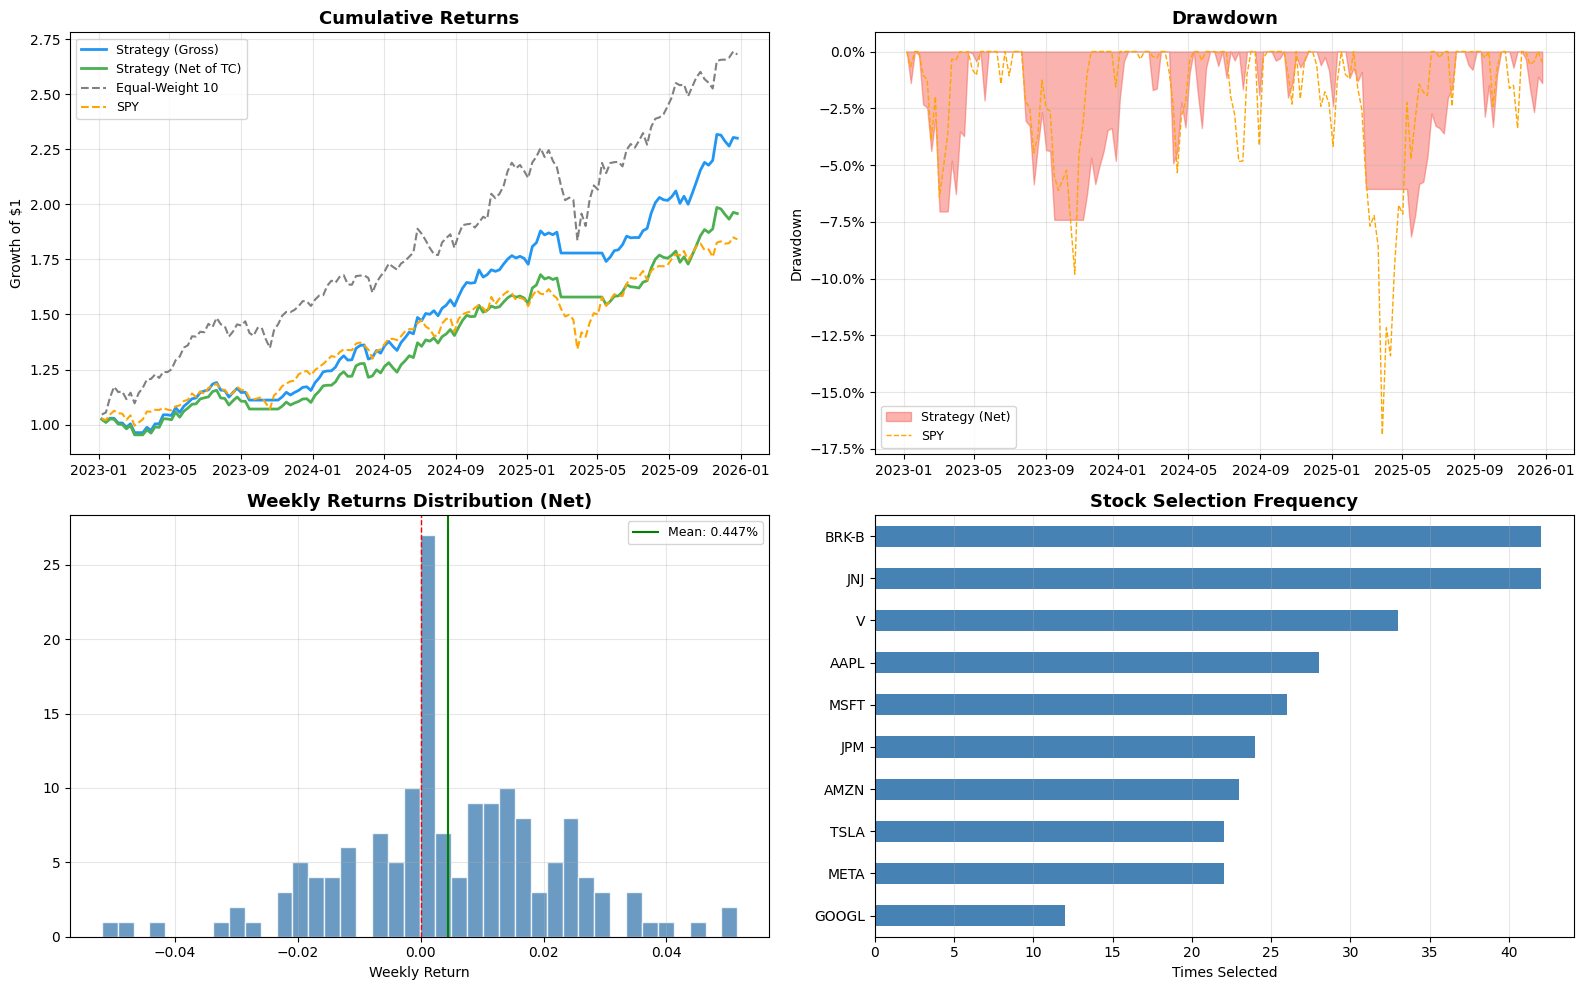

Figure saved to performance_overview.png


In [ ]:
# Cumulative returns
cum_gross = (1 + portfolio_df['return_gross']).cumprod()
cum_net = (1 + portfolio_df['return_net']).cumprod()
cum_bench = (1 + benchmark_ret).cumprod()
cum_spy = (1 + spy_aligned.squeeze()).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot 1: Cumulative Returns ---
ax = axes[0, 0]
ax.plot(cum_gross.index, cum_gross.values, label='Strategy (Gross)', linewidth=2, color='#2196F3')
ax.plot(cum_net.index, cum_net.values, label='Strategy (Net of TC)', linewidth=2, color='#4CAF50')
ax.plot(cum_bench.index, cum_bench.values, label='Equal-Weight 10', linewidth=1.5, color='gray', linestyle='--')
ax.plot(cum_spy.index, cum_spy.values, label='SPY', linewidth=1.5, color='orange', linestyle='--')
ax.set_title('Cumulative Returns', fontsize=13, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Drawdown ---
ax = axes[0, 1]
running_max_net = cum_net.cummax()
dd_net = (cum_net - running_max_net) / running_max_net
running_max_spy = cum_spy.cummax()
dd_spy = (cum_spy - running_max_spy) / running_max_spy

ax.fill_between(dd_net.index, dd_net.values, 0, alpha=0.4, color='#F44336', label='Strategy (Net)')
ax.plot(dd_spy.index, dd_spy.values, color='orange', linewidth=1, label='SPY', linestyle='--')
ax.set_title('Drawdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Weekly Returns Distribution ---
ax = axes[1, 0]
ax.hist(portfolio_df['return_net'].values, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.axvline(portfolio_df['return_net'].mean(), color='green', linestyle='-', linewidth=1.5, label=f'Mean: {portfolio_df["return_net"].mean():.3%}')
ax.set_title('Weekly Returns Distribution (Net)', fontsize=13, fontweight='bold')
ax.set_xlabel('Weekly Return')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 4: Stock Selection Frequency ---
ax = axes[1, 1]
all_picks = portfolio_df['stock_1'].tolist() + portfolio_df['stock_2'].tolist()
pick_counts = pd.Series(all_picks).value_counts().reindex(TICKERS, fill_value=0).sort_values()
pick_counts.plot.barh(ax=ax, color='steelblue')
ax.set_title('Stock Selection Frequency', fontsize=13, fontweight='bold')
ax.set_xlabel('Times Selected')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to performance_overview.png')

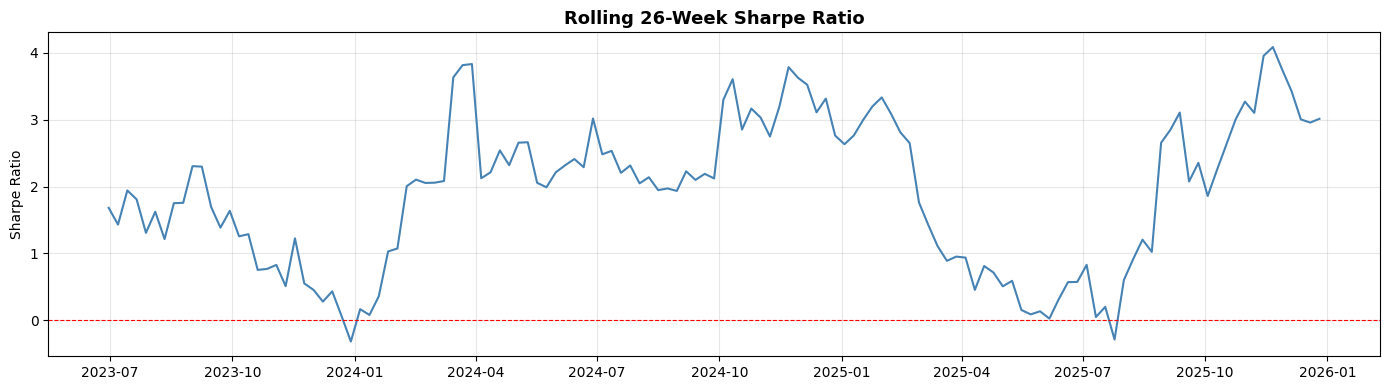

In [ ]:
# Rolling Sharpe Ratio (26-week window)
rolling_window = 26
rolling_mean = portfolio_df['return_net'].rolling(rolling_window).mean()
rolling_std = portfolio_df['return_net'].rolling(rolling_window).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(52)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_sharpe.index, rolling_sharpe.values, color='steelblue', linewidth=1.5)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title(f'Rolling {rolling_window}-Week Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

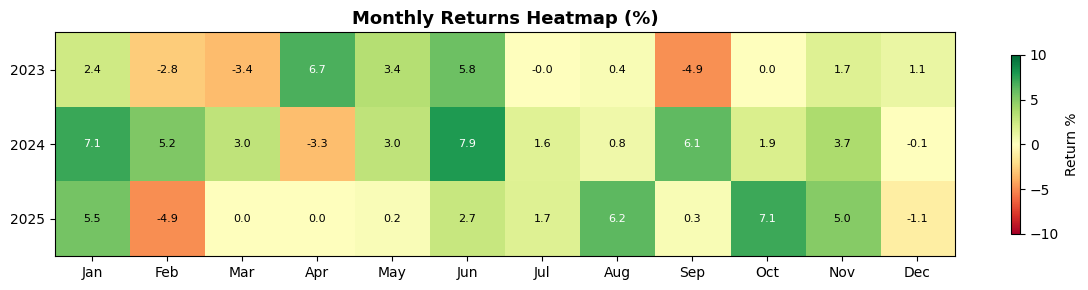

In [ ]:
# Monthly return heatmap
monthly_net = portfolio_df['return_net'].copy()
monthly_net.index = pd.to_datetime(monthly_net.index)
monthly_agg = monthly_net.resample('ME').apply(lambda x: (1 + x).prod() - 1)

monthly_pivot = pd.DataFrame({
    'Year': monthly_agg.index.year,
    'Month': monthly_agg.index.month,
    'Return': monthly_agg.values
}).pivot(index='Year', columns='Month', values='Return')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_pivot.columns = [month_names[m - 1] for m in monthly_pivot.columns]

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(monthly_pivot.values * 100, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=10)
ax.set_xticks(range(len(monthly_pivot.columns)))
ax.set_xticklabels(monthly_pivot.columns)
ax.set_yticks(range(len(monthly_pivot.index)))
ax.set_yticklabels(monthly_pivot.index)
ax.set_title('Monthly Returns Heatmap (%)', fontsize=13, fontweight='bold')

for i in range(len(monthly_pivot.index)):
    for j in range(len(monthly_pivot.columns)):
        val = monthly_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val*100:.1f}', ha='center', va='center', fontsize=8,
                    color='black' if abs(val) < 0.06 else 'white')

plt.colorbar(im, ax=ax, label='Return %', shrink=0.8)
plt.tight_layout()
plt.show()

## 11. Export CSV Deliverables

In [ ]:
# CSV 1: Weekly Predictions (all stocks)
pred_records = []
for _, row in test.iterrows():
    pred_records.append({
        'week': row['week'].date(),
        'ticker': row['ticker'],
        'pred_prob_positive': round(row['pred_prob'], 4),
        'pred_class': int(row['pred']),
        'actual_class': int(row['target'])
    })

pred_csv = pd.DataFrame(pred_records)
pred_csv.to_csv('weekly_predictions.csv', index=False)
print(f'Saved weekly_predictions.csv ({pred_csv.shape[0]} rows)')
pred_csv.head(10)

Saved weekly_predictions.csv (1569 rows)


,week,ticker,pred_prob_positive,pred_class,actual_class
0,2023-01-06,AAPL,0.4410,0,1
1,2023-01-13,AAPL,0.5117,1,1
2,2023-01-20,AAPL,0.5054,1,1
3,2023-01-27,AAPL,0.2965,0,1
4,2023-02-03,AAPL,0.5268,1,0
5,2023-02-10,AAPL,0.5767,1,1
6,2023-02-17,AAPL,0.4946,0,0
7,2023-02-24,AAPL,0.4572,0,1
8,2023-03-03,AAPL,0.6317,1,0
9,2023-03-10,AAPL,0.5160,1,1


In [ ]:
# CSV 2: Portfolio selections and weights
export_cols = ['next_week', 'stock_1', 'stock_2', 'weight_1', 'weight_2',
               'return_gross', 'turnover_cost', 'return_net', 'regime']
if TOP_K >= 3 and 'stock_3' in portfolio_df.columns:
    export_cols = ['next_week', 'stock_1', 'stock_2', 'stock_3',
                   'weight_1', 'weight_2', 'weight_3',
                   'return_gross', 'turnover_cost', 'return_net', 'regime']

port_csv = portfolio_df[export_cols].copy()
port_csv.index = port_csv.index.map(lambda x: x.date())
port_csv.index.name = 'rebalance_date'
port_csv['next_week'] = port_csv['next_week'].apply(lambda x: x.date())
port_csv.to_csv('portfolio_selections.csv')
print(f'Saved portfolio_selections.csv ({port_csv.shape[0]} rows)')
port_csv.head(10)

Saved portfolio_selections.csv (156 rows)


,next_week,stock_1,stock_2,stock_3,weight_1,weight_2,weight_3,return_gross,turnover_cost,return_net,regime
rebalance_date,,,,,,,,,,,
2023-01-06,2023-01-13,JPM,TSLA,BRK-B,0.4984,0.0909,0.4107,0.0245,0.0010,0.0235,1
2023-01-13,2023-01-20,BRK-B,AMZN,MSFT,0.4841,0.2194,0.2964,-0.0126,0.0013,-0.0139,1
2023-01-20,2023-01-27,BRK-B,JPM,GOOGL,0.3809,0.3800,0.2392,0.0172,0.0013,0.0158,1
2023-01-27,2023-02-03,JPM,V,BRK-B,0.3158,0.3168,0.3675,-0.0008,0.0007,-0.0015,1
2023-02-03,2023-02-10,JNJ,BRK-B,GOOGL,0.3903,0.4393,0.1704,-0.0205,0.0013,-0.0218,1
2023-02-10,2023-02-17,META,BRK-B,JPM,0.0885,0.5247,0.3868,-0.0001,0.0013,-0.0015,1
2023-02-17,2023-02-24,BRK-B,JNJ,META,0.5499,0.3736,0.0765,-0.0189,0.0007,-0.0196,1
2023-02-24,2023-03-03,JNJ,META,GOOGL,0.6314,0.1332,0.2354,0.0157,0.0007,0.0150,1
2023-03-03,2023-03-10,BRK-B,AAPL,JPM,0.4135,0.2340,0.3525,-0.0402,0.0020,-0.0422,1


## 12. Summary

### Assumptions
- **Slippage:** Not modeled separately; assumed captured within the 0.1% entry + 0.1% exit transaction cost.
- **Execution:** Trades are executed at the Friday close price.
- **Data:** Adjusted close prices used (stock splits and dividends accounted for via `auto_adjust=True`).
- **No short selling:** The strategy is strictly long-only.
- **No leverage:** Fully funded positions.
- **Survivorship bias:** All 10 stocks survived and remained large-cap throughout 2017–2025. The universe is therefore subject to survivorship bias, which likely inflates backtest returns modestly.

### Strategy Logic
1. Compute 13 momentum and technical features for each stock on a weekly basis.
2. Train an ensemble classifier (Logistic Regression + Random Forest + XGBoost) on 2017–2022 data.
3. Validate model with 5-fold TimeSeriesSplit cross-validation on training data.
4. Each week during 2023–2025, predict P(positive return) for all 10 stocks.
5. Select the top 2 stocks by predicted probability.
6. Hold an equal-weight portfolio for 1 week, then rebalance.
7. Transaction costs (0.2% round-trip) applied only to changed positions.

### Evaluation Metrics Explained
| Metric | What it measures |
|---|---|
| Sharpe Ratio | Risk-adjusted return (annualised return / annualised volatility) |
| Calmar Ratio | Return per unit of drawdown risk (annualised return / max drawdown) |
| Max Drawdown | Largest peak-to-trough loss during the test period |
| Hit Rate | Fraction of weeks with positive portfolio return |
| SPY Correlation | How much strategy returns move with the market |

In [ ]:
# Final summary print
print('=' * 60)
print('       PERFORMANCE SUMMARY')
print('=' * 60)
print(metrics_table.to_string())
print('=' * 60)
print(f'\nTotal turnover events (stock changes): {portfolio_df["n_changes"].sum()}')
print(f'Average weekly turnover cost: {portfolio_df["turnover_cost"].mean():.4%}')
print(f'Total transaction costs paid: {portfolio_df["turnover_cost"].sum():.4%}')
print(f'\nStrategy vs SPY correlation: {portfolio_df["return_net"].corr(spy_aligned.squeeze()):.3f}')
print(f'\nFiles generated:')
print(f'  - weekly_predictions.csv')
print(f'  - portfolio_selections.csv')
print(f'  - performance_overview.png')

       PERFORMANCE SUMMARY
                       Cumulative Return Annualized Return Annualized Volatility Sharpe Ratio Calmar Ratio Max Drawdown Hit Rate Avg Weekly Return  Total Weeks
Name                                                                                                                                                           
Strategy (Before TC)             130.15%            32.03%                12.63%        2.536        4.345       -7.37%   56.41%           0.5510%          156
Strategy (After TC)               95.88%            25.12%                12.62%        1.991        3.082       -8.15%   54.49%           0.4471%          156
Equal-Weight 10 Stocks           168.18%            38.93%                17.01%        2.289        2.094      -18.59%   63.46%           0.6619%          156
SPY                               84.16%            22.57%                14.40%        1.567        1.338      -16.88%   59.62%           0.4121%          156

Total turnov